# Simple linear regression Neural Network style

Logistic Regression from Scratch
═══════════════════════════════════════════════════════════════════════════════
Dataset : Synthetic TCGA-mirrored RNA-Seq
          802 samples × 20,531 gene features
          Matches TCGA statistical properties:
            · Log-normal expression distribution (μ=6, σ=2 per gene)
            · 500 differentially expressed genes per class
            · Class-specific expression shifts drawn from N(0, 1.5)
            · Gaussian noise σ=0.5 per sample
Task    : Binary classification — BRCA (breast) vs LUAD (lung adenocarcinoma)
Model   : Single-layer neural network (logistic regression) with mini-batch SGD

In [1]:
"""
To run on the real TCGA dataset, replace Section 1 with:
      X_df  = pd.read_csv("TCGA-PANCAN.../data.csv",   index_col=0)
      y_raw = pd.read_csv("TCGA-PANCAN.../labels.csv", index_col=0).squeeze()
      mask  = y_raw.isin(["BRCA","LUAD"])
      X_all = X_df[mask].values
      y_all = (y_raw[mask]=="BRCA").astype(int).values
  Everything downstream is identical.

  """

'\nTo run on the real TCGA dataset, replace Section 1 with:\n      X_df  = pd.read_csv("TCGA-PANCAN.../data.csv",   index_col=0)\n      y_raw = pd.read_csv("TCGA-PANCAN.../labels.csv", index_col=0).squeeze()\n      mask  = y_raw.isin(["BRCA","LUAD"])\n      X_all = X_df[mask].values\n      y_all = (y_raw[mask]=="BRCA").astype(int).values\n  Everything downstream is identical.\n\n  '

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
#get your working directory path
cwd = os.getcwd()
print("Current working directory:", cwd)

Current working directory: /Users/blaiseenuh/Documents/ML-DL_Notes


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# 1.  DATA  —  synthetic TCGA-mirrored RNA-Seq
# ══════════════════════════════════════════════════════════════════════════════

N_SAMPLES = 802          # 401 BRCA + 401 LUAD  (mirrors TCGA class balance)
N_GENES   = 20_531       # matches TCGA-PANCAN dimensionality
N_DE      = 500          # differentially expressed genes per class

def make_tcga_like(n=N_SAMPLES, p=N_GENES, n_de=N_DE, seed=42):
    """
    Simulate RNA-Seq expression profiles.
    Each gene: log-normal baseline + class-specific shift for DE genes.
    """
    rng = np.random.default_rng(seed)

    # ── baseline: log-normal  (exp( N(6,2) ) mimics real counts) ──────────────
    log_mean = rng.normal(6.0, 2.0, size=p)        # per-gene mean in log space
    log_std  = rng.uniform(0.3, 1.5, size=p)       # per-gene variance

    n_brca = n // 2;  n_luad = n - n_brca
    y = np.array([1]*n_brca + [0]*n_luad)

    # ── differential expression: random subset of genes ───────────────────────
    de_brca = rng.choice(p, n_de, replace=False)   # up-regulated in BRCA
    de_luad = rng.choice(p, n_de, replace=False)   # up-regulated in LUAD
    de_shift_brca = rng.normal(0, 1.5, n_de)
    de_shift_luad = rng.normal(0, 1.5, n_de)

    # ── build expression matrix in log-space ──────────────────────────────────
    X = np.zeros((n, p))
    for i in range(n):
        base = rng.normal(log_mean, log_std)        # sample from gene baseline
        if y[i] == 1:                               # BRCA
            base[de_brca] += de_shift_brca
        else:                                       # LUAD
            base[de_luad] += de_shift_luad
        base += rng.normal(0, 0.5, p)              # per-sample noise
        X[i] = np.exp(base)                         # back to expression space

    gene_names = [f"gene_{i:05d}" for i in range(p)]
    return pd.DataFrame(X, columns=gene_names), y

print("Generating synthetic TCGA-mirrored RNA-Seq dataset…")
X_df, y_all = make_tcga_like()
print(f"Dataset : {X_df.shape}  BRCA={y_all.sum()}  LUAD={(y_all==0).sum()}\n")


Generating synthetic TCGA-mirrored RNA-Seq dataset…
Dataset : (802, 20531)  BRCA=401  LUAD=401



In [9]:
X_df.shape, y_all.shape

((802, 20531), (802,))

In [10]:
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")

In [11]:
#Preprocessing

# Variance filter: keep top-1 000 most variable genes (speeds up training)
top_genes = X_df.var(axis=0).nlargest(1000).index
X_all     = X_df[top_genes].values

# Standardise
scaler = StandardScaler()
X_all  = scaler.fit_transform(X_all)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")


Train : (641, 1000)  |  Test : (161, 1000)


In [12]:
    """
    Minimalistic logistic regression implemented as a 1-layer neural network.

        z     = X @ W + b          (linear transform)
        ŷ     = σ(z)               (sigmoid activation)
        L     = BCE(y, ŷ) + λ‖W‖² (loss with L2 regularisation)
        ∂L/∂W = Xᵀ(ŷ-y)/n + 2λW   (gradient, closed-form)
    """

'\nMinimalistic logistic regression implemented as a 1-layer neural network.\n\n    z     = X @ W + b          (linear transform)\n    ŷ     = σ(z)               (sigmoid activation)\n    L     = BCE(y, ŷ) + λ‖W‖² (loss with L2 regularisation)\n    ∂L/∂W = Xᵀ(ŷ-y)/n + 2λW   (gradient, closed-form)\n'

In [8]:
#We will fix this later

class LogisticRegression:    
    def __init__(self, lr=0.05, epochs=300, batch_size=32, lam=1e-3):
        self.lr, self.epochs = lr, epochs
        self.batch_size, self.lam = batch_size, lam
        self.train_losses, self.val_losses = [], []

print("\nTraining…")
#model = LogisticRegression(lr=0.05, epochs=300, batch_size=32, lam=1e-3)
#model.fit(X_train, y_train, X_val=X_test, y_val=y_test)


Training…


In [13]:
def _sigmoid(self, z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

In [14]:
def _bce(self, y, p):
        p = np.clip(p, 1e-9, 1 - 1e-9)
        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


In [ ]:
def fit(self, X, y, X_val=None, y_val=None):
        n, d = X.shape
        #initialise parameters
        self.W = np.zeros(d)           # weight vector
        self.b = 0.0                   # bias

        #training loop.
        for epoch in range(self.epochs):
            idx = np.random.permutation(n)

            # ── mini-batch gradient descent ───────────────────────────────────
            for s in range(0, n, self.batch_size):
                bx, by = X[idx[s:s+self.batch_size]], y[idx[s:s+self.batch_size]]
                err    = self._sigmoid(bx @ self.W + self.b) - by # @ here is used for matrix multiplication.
                self.W -= self.lr * ((bx.T @ err) / len(by) + 2 * self.lam * self.W)
                self.b -= self.lr * err.mean()

            # ── epoch metrics ─────────────────────────────────────────────────
            self.train_losses.append(self._bce(y,     self._sigmoid(X     @ self.W + self.b)))
            if X_val is not None:
                self.val_losses.append(self._bce(y_val, self._sigmoid(X_val @ self.W + self.b)))

            if epoch % 50 == 0:
                msg = f"  epoch {epoch:3d}  train_loss={self.train_losses[-1]:.4f}"
                if X_val is not None:
                    msg += f"  val_loss={self.val_losses[-1]:.4f}"
                print(msg)

        return self

In [12]:
def predict_proba(self, X):
        return self._sigmoid(X @ self.W + self.b)

In [13]:
def predict(self, X, thresh=0.5):
    return (self.predict_proba(X) >= thresh).astype(int)

In [14]:
class LogisticRegression:
    """
    Minimalistic logistic regression implemented as a 1-layer neural network.

        z     = X @ W + b          (linear transform)
        ŷ     = σ(z)               (sigmoid activation)
        L     = BCE(y, ŷ) + λ‖W‖² (loss with L2 regularisation)
        ∂L/∂W = Xᵀ(ŷ-y)/n + 2λW   (gradient, closed-form)
    """

    def __init__(self, lr=0.05, epochs=300, batch_size=32, lam=1e-3):
        self.lr, self.epochs = lr, epochs
        self.batch_size, self.lam = batch_size, lam
        self.train_losses, self.val_losses = [], []

    # ── core ops ──────────────────────────────────────────────────────────────
    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def _bce(self, y, p):
        p = np.clip(p, 1e-9, 1 - 1e-9)
        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

    # ── training ──────────────────────────────────────────────────────────────
    def fit(self, X, y, X_val=None, y_val=None):
        n, d = X.shape
        self.W = np.zeros(d)           # weight vector
        self.b = 0.0                   # bias

        for epoch in range(self.epochs):
            idx = np.random.permutation(n)

            # ── mini-batch gradient descent ───────────────────────────────────
            for s in range(0, n, self.batch_size):
                bx, by = X[idx[s:s+self.batch_size]], y[idx[s:s+self.batch_size]]
                err    = self._sigmoid(bx @ self.W + self.b) - by
                self.W -= self.lr * ((bx.T @ err) / len(by) + 2 * self.lam * self.W)
                self.b -= self.lr * err.mean()

            # ── epoch metrics ─────────────────────────────────────────────────
            self.train_losses.append(self._bce(y,     self._sigmoid(X     @ self.W + self.b)))
            if X_val is not None:
                self.val_losses.append(self._bce(y_val, self._sigmoid(X_val @ self.W + self.b)))

            if epoch % 50 == 0:
                msg = f"  epoch {epoch:3d}  train_loss={self.train_losses[-1]:.4f}"
                if X_val is not None:
                    msg += f"  val_loss={self.val_losses[-1]:.4f}"
                print(msg)

        return self

    # ── inference ─────────────────────────────────────────────────────────────
    def predict_proba(self, X):
        return self._sigmoid(X @ self.W + self.b)

    def predict(self, X, thresh=0.5):
        return (self.predict_proba(X) >= thresh).astype(int)


print("\nTraining…")
model = LogisticRegression(lr=0.05, epochs=300, batch_size=32, lam=1e-3)
model.fit(X_train, y_train, X_val=X_test, y_val=y_test)



Training…
  epoch   0  train_loss=0.1098  val_loss=0.1675
  epoch  50  train_loss=0.0038  val_loss=0.0206
  epoch 100  train_loss=0.0025  val_loss=0.0168
  epoch 150  train_loss=0.0022  val_loss=0.0157
  epoch 200  train_loss=0.0020  val_loss=0.0155
  epoch 250  train_loss=0.0020  val_loss=0.0154


In [15]:
y_prob = model.predict_proba(X_test)
y_pred = model.predict(X_test)

TP = int(((y_pred==1)&(y_test==1)).sum())
TN = int(((y_pred==0)&(y_test==0)).sum())
FP = int(((y_pred==1)&(y_test==0)).sum())
FN = int(((y_pred==0)&(y_test==1)).sum())

acc       = (TP + TN) / len(y_test)
precision = TP / (TP + FP + 1e-9)
recall    = TP / (TP + FN + 1e-9)
f1        = 2 * precision * recall / (precision + recall + 1e-9)

In [16]:
def roc_points(y_true, scores, n=300):
    fprs, tprs = [], []
    for t in np.linspace(0, 1, n):
        p  = (scores >= t).astype(int)
        tp = ((p==1)&(y_true==1)).sum()
        fp = ((p==1)&(y_true==0)).sum()
        fn = ((p==0)&(y_true==1)).sum()
        tn = ((p==0)&(y_true==0)).sum()
        tprs.append(tp / (tp + fn + 1e-9))
        fprs.append(fp / (fp + tn + 1e-9))
    return np.array(fprs), np.array(tprs)

In [17]:
def pr_points(y_true, scores, n=300):
    precs, recs = [], []
    for t in np.linspace(0, 1, n):
        p  = (scores >= t).astype(int)
        tp = ((p==1)&(y_true==1)).sum()
        fp = ((p==1)&(y_true==0)).sum()
        fn = ((p==0)&(y_true==1)).sum()
        precs.append(tp / (tp + fp + 1e-9))
        recs.append(tp  / (tp + fn + 1e-9))
    return np.array(recs), np.array(precs)

In [18]:
fpr, tpr       = roc_points(y_test, y_prob)
auc            = float(-np.trapezoid(tpr, fpr))
rec_c, prec_c  = pr_points(y_test, y_prob)

In [19]:
print(f"\n{'─'*50}")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1        : {f1:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print(f"  TP={TP}  TN={TN}  FP={FP}  FN={FN}")
print(f"{'─'*50}\n")


──────────────────────────────────────────────────
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1        : 1.0000
  AUC-ROC   : 1.0000
  TP=80  TN=81  FP=0  FN=0
──────────────────────────────────────────────────



In [44]:
#plots

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap

C = dict(brca="#E63946", luad="#457B9D", loss="#2A9D8F",
         val="#E9C46A", mis="black", bar_pos="#E63946", bar_neg="#457B9D")

TITLE = "Logistic Regression · TCGA RNA-Seq · BRCA vs LUAD"
OUT   = cwd  # save plots to current working directory

# shared PCA fitted once, reused across plot 5, 6, 7
pca   = PCA(n_components=2, random_state=42)
Z     = pca.fit_transform(X_test)
wrong = y_pred != y_test

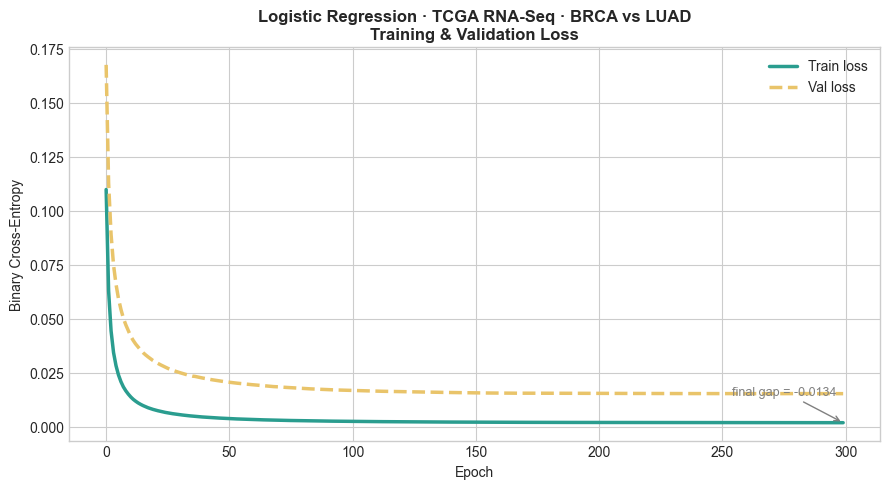

Saved plot1_loss_curves.png


In [52]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Training & Validation Loss
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(model.train_losses, lw=2.5, color=C["loss"], label="Train loss")
ax.plot(model.val_losses,   lw=2.5, color=C["val"],  label="Val loss", ls="--")

gap = model.train_losses[-1] - model.val_losses[-1]
ax.annotate(f"final gap = {gap:+.4f}",
            xy=(len(model.train_losses)-1, model.train_losses[-1]),
            xytext=(-80, 20), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="gray"),
            fontsize=9, color="gray")

ax.set_title(f"{TITLE}\nTraining & Validation Loss", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary Cross-Entropy")
ax.legend(framealpha=0.9)
fig.tight_layout()
fig.savefig(f"{os.path.join(cwd, 'plot1_loss_curves.png')}", dpi=150, bbox_inches="tight")
plt.show(fig)
print("Saved plot1_loss_curves.png")

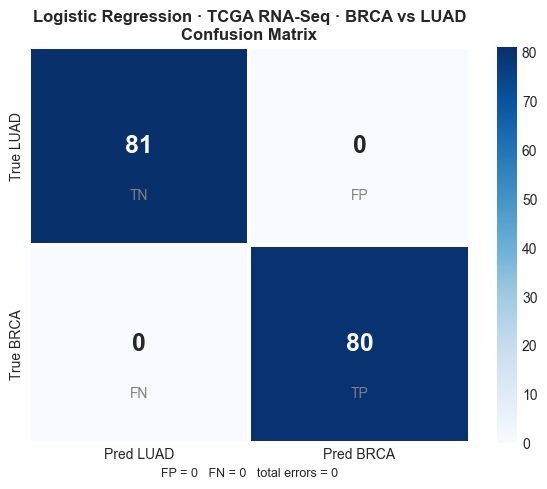

Saved plot2_confusion_matrix.png


In [53]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Confusion Matrix
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(6, 5))

cm = np.array([[TN, FP], [FN, TP]])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            linewidths=1.5, linecolor="white",
            xticklabels=["Pred LUAD", "Pred BRCA"],
            yticklabels=["True LUAD", "True BRCA"],
            annot_kws={"size": 18, "weight": "bold"})

# label each cell explicitly
for (r, c), val in np.ndenumerate(cm):
    label = {(0,0):"TN", (0,1):"FP", (1,0):"FN", (1,1):"TP"}[(r,c)]
    ax.text(c + 0.5, r + 0.75, label, ha="center", va="center",
            fontsize=10, color="gray")

ax.set_title(f"{TITLE}\nConfusion Matrix", fontweight="bold")
ax.set_xlabel(f"FP = {FP}   FN = {FN}   total errors = {FP+FN}", fontsize=9)
fig.tight_layout()
fig.savefig(f"{OUT}/plot2_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show(fig)
print("Saved plot2_confusion_matrix.png")

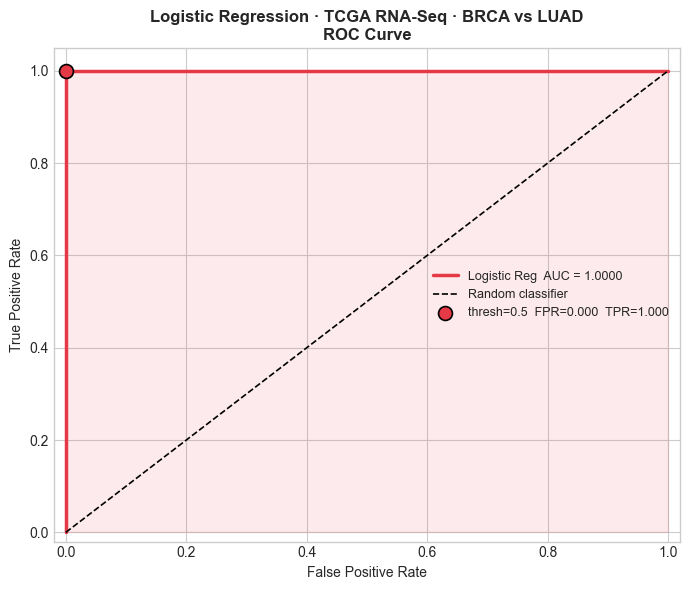

Saved plot3_roc_curve.png


In [54]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — ROC Curve
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, lw=2.5, color=C["brca"], label=f"Logistic Reg  AUC = {auc:.4f}")
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random classifier")
ax.fill_between(fpr, tpr, alpha=0.10, color=C["brca"])

# annotate operating point at default threshold 0.5
op_idx = np.argmin(np.abs(np.linspace(0, 1, len(fpr)) - 0.5))
ax.scatter(fpr[op_idx], tpr[op_idx], s=100, zorder=5,
           color=C["brca"], edgecolors="black", lw=1.2,
           label=f"thresh=0.5  FPR={fpr[op_idx]:.3f}  TPR={tpr[op_idx]:.3f}")

ax.set_title(f"{TITLE}\nROC Curve", fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=9, framealpha=0.9)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
fig.tight_layout()
fig.savefig(f"{OUT}/plot3_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show(fig)
print("Saved plot3_roc_curve.png")


TypeError: Figure.show() got an unexpected keyword argument 'dpi'

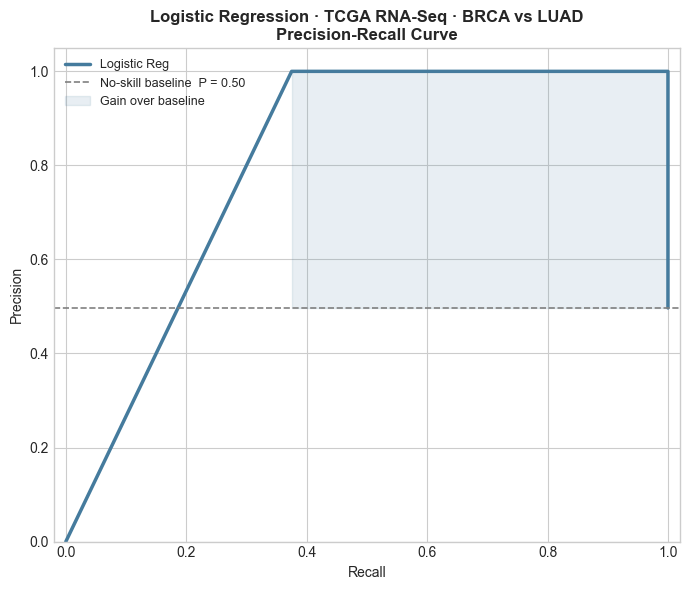

In [55]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — Precision-Recall Curve
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 6))

base = y_test.mean()
ax.plot(rec_c, prec_c, lw=2.5, color=C["luad"], label="Logistic Reg")
ax.axhline(base, ls="--", color="gray", lw=1.2,
           label=f"No-skill baseline  P = {base:.2f}")
ax.fill_between(rec_c, prec_c, base, where=(prec_c >= base),
                alpha=0.12, color=C["luad"], label="Gain over baseline")

ax.set_title(f"{TITLE}\nPrecision-Recall Curve", fontweight="bold")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, framealpha=0.9)
fig.tight_layout()
fig.show(f"{OUT}/plot4_precision_recall.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved plot4_precision_recall.png")

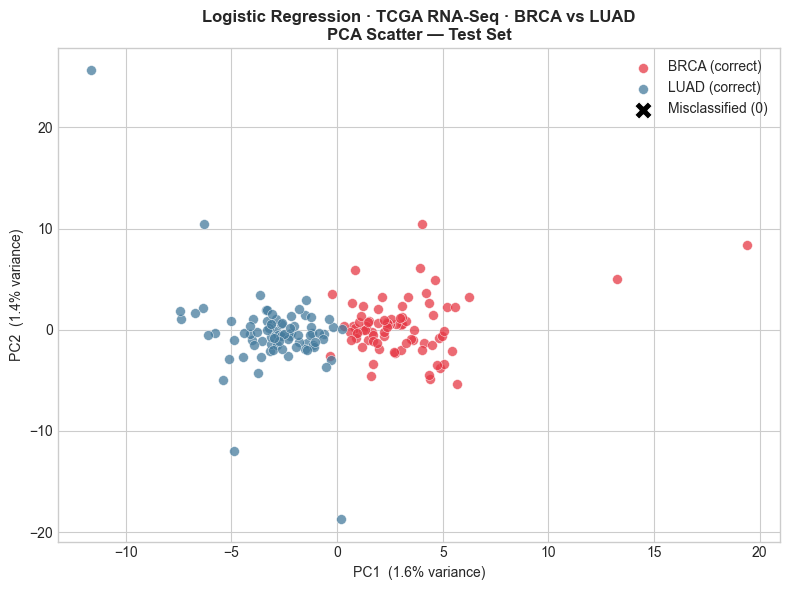

Saved plot5_pca_scatter.png


In [56]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 5 — PCA Scatter + Misclassifications
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))

for label, color, name in [(1, C["brca"], "BRCA"), (0, C["luad"], "LUAD")]:
    m = (y_test == label) & (~wrong)
    ax.scatter(Z[m, 0], Z[m, 1], c=color, alpha=0.75, s=50,
               edgecolors="white", lw=0.4, zorder=2, label=f"{name} (correct)")

ax.scatter(Z[wrong, 0], Z[wrong, 1], marker="X", s=160,
           c=C["mis"], edgecolors="white", lw=0.8,
           zorder=3, label=f"Misclassified ({wrong.sum()})")

ax.set_title(f"{TITLE}\nPCA Scatter — Test Set", fontweight="bold")
ax.set_xlabel(f"PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend(framealpha=0.9)
fig.tight_layout()
fig.savefig(f"{OUT}/plot5_pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show(fig)
print("Saved plot5_pca_scatter.png")

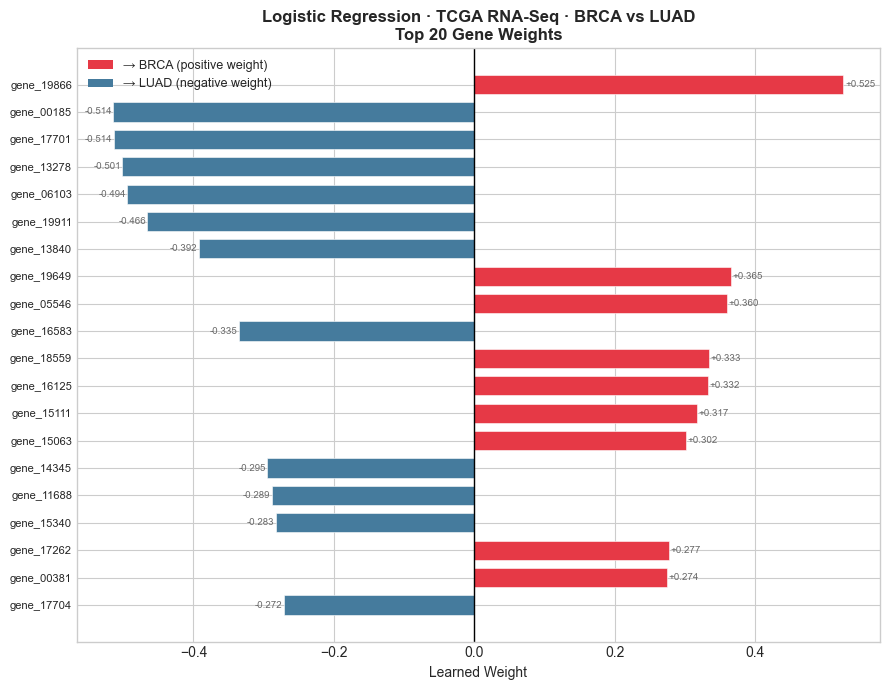

Saved plot6_gene_weights.png


In [57]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 6 — Top-20 Gene Weights
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 7))

top_i   = np.argsort(np.abs(model.W))[-20:][::-1]
w_vals  = model.W[top_i]
g_names = [top_genes[i] for i in top_i]
colors  = [C["bar_pos"] if w > 0 else C["bar_neg"] for w in w_vals]

bars = ax.barh(range(20), w_vals[::-1],
               color=colors[::-1], edgecolor="white", lw=0.4, height=0.7)

# value labels on each bar
for bar, val in zip(bars, w_vals[::-1]):
    xpos = bar.get_width() + (0.002 if val >= 0 else -0.002)
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=7, color="dimgray")

ax.set_yticks(range(20))
ax.set_yticklabels(g_names[::-1], fontsize=8)
ax.axvline(0, color="black", lw=1.0)

legend_handles = [
    Patch(facecolor=C["bar_pos"], label="→ BRCA (positive weight)"),
    Patch(facecolor=C["bar_neg"], label="→ LUAD (negative weight)"),
]
ax.legend(handles=legend_handles, fontsize=9, framealpha=0.9)
ax.set_title(f"{TITLE}\nTop 20 Gene Weights", fontweight="bold")
ax.set_xlabel("Learned Weight")
fig.tight_layout()
fig.savefig(f"{OUT}/plot6_gene_weights.png", dpi=150, bbox_inches="tight")
plt.show(fig)
print("Saved plot6_gene_weights.png")

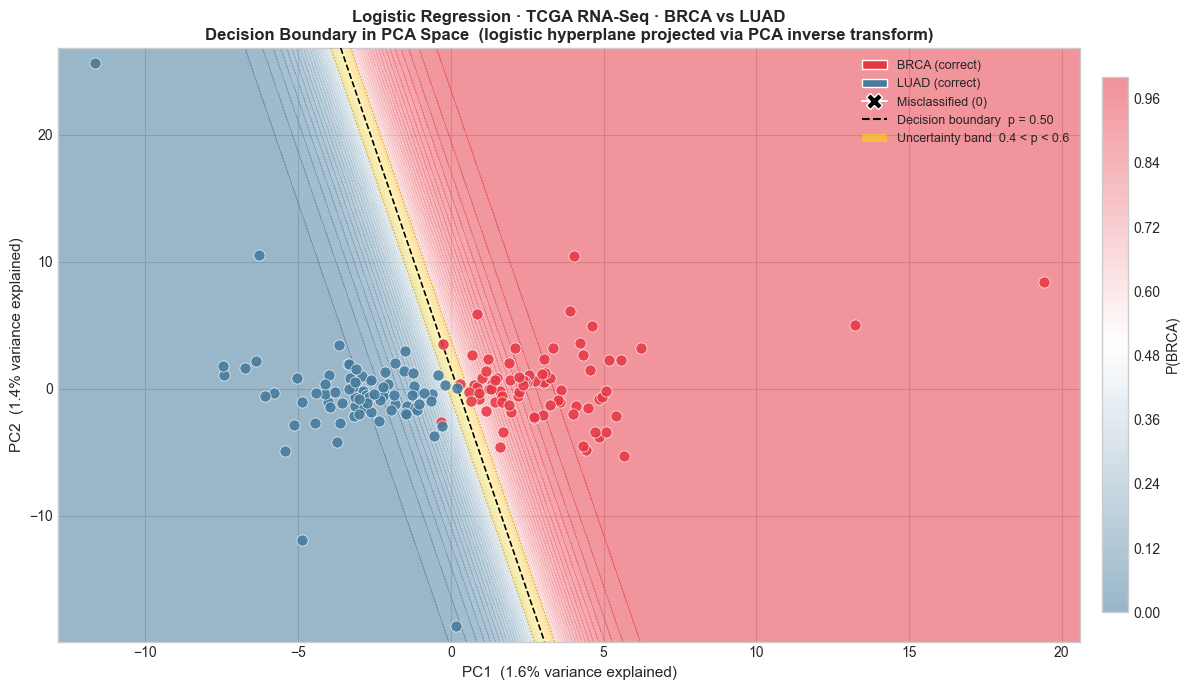

Saved plot7_decision_boundary.png

All 7 plots saved to /Users/blaiseenuh/Documents/ML-DL_Notes


In [58]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 7 — Decision Boundary in PCA Space
# ══════════════════════════════════════════════════════════════════════════════
#
# Strategy:
#   1. Dense meshgrid over the 2D PCA plane (PC1 × PC2)
#   2. pca.inverse_transform → reconstruct approximate 1000-gene vectors
#   3. model.predict_proba → P(BRCA) at every grid point
#   4. contourf paints the probability field
#   5. contour at p=0.50 is the true logistic hyperplane projected into this plane
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

pad  = 1.2
x1s  = np.linspace(Z[:, 0].min() - pad, Z[:, 0].max() + pad, 500)
x2s  = np.linspace(Z[:, 1].min() - pad, Z[:, 1].max() + pad, 400)
xx1, xx2  = np.meshgrid(x1s, x2s)
grid_2d   = np.c_[xx1.ravel(), xx2.ravel()]
grid_feat = pca.inverse_transform(grid_2d)
grid_prob = model.predict_proba(grid_feat).reshape(xx1.shape)

boundary_cmap = LinearSegmentedColormap.from_list(
    "boundary", [C["luad"], "#FFFFFF", C["brca"]], N=256
)
cf = ax.contourf(xx1, xx2, grid_prob, levels=60,
                 cmap=boundary_cmap, alpha=0.55, zorder=1)
plt.colorbar(cf, ax=ax, label="P(BRCA)", fraction=0.025, pad=0.02)

# hard boundary p = 0.5
ax.contour(xx1, xx2, grid_prob, levels=[0.5],
           colors="white",  linewidths=3.0, zorder=2)
ax.contour(xx1, xx2, grid_prob, levels=[0.5],
           colors="black",  linewidths=1.2, linestyles="--", zorder=3)

# uncertainty band 0.4 < p < 0.6
ax.contourf(xx1, xx2, grid_prob, levels=[0.4, 0.6],
            colors=["gold"], alpha=0.28, zorder=2)
ax.contour(xx1, xx2, grid_prob, levels=[0.4, 0.6],
           colors=["goldenrod"], linewidths=0.9, linestyles=":", zorder=3)

# correct points
for label, color, name in [(1, C["brca"], "BRCA"), (0, C["luad"], "LUAD")]:
    m = (y_test == label) & (~wrong)
    ax.scatter(Z[m, 0], Z[m, 1], c=color, edgecolors="white",
               linewidths=0.5, s=65, alpha=0.88, zorder=4, label=f"{name} correct")

# misclassified
ax.scatter(Z[wrong, 0], Z[wrong, 1], marker="X", s=200,
           c="black", edgecolors="white", linewidths=0.9,
           zorder=5, label=f"Misclassified ({wrong.sum()})")

legend_handles = [
    Patch(facecolor=C["brca"], edgecolor="white", label="BRCA (correct)"),
    Patch(facecolor=C["luad"], edgecolor="white", label="LUAD (correct)"),
    Line2D([0],[0], marker="X", color="w", markerfacecolor="black",
           markersize=11, label=f"Misclassified ({wrong.sum()})"),
    Line2D([0],[0], color="black", lw=1.5, ls="--",
           label="Decision boundary  p = 0.50"),
    Patch(facecolor="gold", alpha=0.55,
          label="Uncertainty band  0.4 < p < 0.6"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9, framealpha=0.92)
ax.set_title(
    f"{TITLE}\nDecision Boundary in PCA Space  "
    f"(logistic hyperplane projected via PCA inverse transform)",
    fontweight="bold"
)
ax.set_xlabel(f"PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)", fontsize=11)
ax.set_ylabel(f"PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% variance explained)", fontsize=11)
fig.tight_layout()
#fig.savefig(f"{os.path.join(cwd, 'plot7_decision_boundary.png')}", dpi=150, bbox_inches="tight")
plt.show(fig)
print("Saved plot7_decision_boundary.png")

print("\nAll 7 plots saved to", cwd)